In [1]:
import xarray as xr
import numpy as np
import functions
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.markers import MarkerStyle
import statsmodels.api as sm
import pymannkendall as mk
from global_land_mask import globe
import glob

import warnings
warnings.filterwarnings('ignore')


# Temporal and spatial defintions

In [2]:
Arctic_limit = 60
land_longitudes = slice(0,300) # Exclude Greenland
spring_summer_months = [4, 5, 6, 7, 8]
spring_summer_label = 'AMJJA'
summer_months = [6, 7, 8]

# Observational data

In [3]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
start_year = 2003
end_year = 2025

## Extract data and calculate spatial averages

### Snow cover data

Url: https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00756

Robinson, David A.; Estilow, Thomas W.; and NOAA CDR Program (2012): NOAA Climate Data Record (CDR) of Northern Hemisphere (NH) Snow Cover Extent (SCE), Version 1. NOAA National Centers for Environmental Information. doi:10.7289/V5N014G9 [20.02.2026].

In [4]:
sce = xr.open_dataset(rpath+'nhsce_v01r01_19661004_20260202.nc')

# Select times with meaningful data
sce = sce.sel(time=slice('1975-01-01','2026-01-01'))

# Select area
land_weights = sce.land # Extract land weights
latitude_weights = sce.latitude >= Arctic_limit # Select latitudes
longitude_weights = 1-(sce.longitude >= -60)*(sce.longitude <=0) # Select longitudes, i.e. longitudes between 0 and 300 degrees east
total_weights = land_weights*longitude_weights*latitude_weights # Create weights that include all selected land areas

# Calculate area-weighted average snow cover extent across area
area_weights = sce.area
total_weights_area = (area_weights*total_weights)
total_area = total_weights_area.sum() # Find total area sum for seleced grid boxes
snow_cover_extent = (sce['snow_cover_extent']*total_weights_area/total_area).sum(('y','x'))

#Convert from fraction to percentage
snow_cover_extent = snow_cover_extent*100

### Soil moisture data

In [5]:
SM_ERA5 = xr.open_dataset(rpath+'SM_ERA5_1970_2025_10cm_20cm.nc')

# Convert units from m3/m3 to kg/m2
SM_ERA5_converted = SM_ERA5['swvl_10cm']*100 # Conversion factor = 1000 kg/m3 * 0.10 m

# Calculate area-weighted regional average
SM_ERA5 = functions.computeWeightedMean(SM_ERA5_converted.sel(lon=land_longitudes))

### Cloud cover data

In [6]:
CERES  = xr.open_dataset(rpath+'CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202512.nc')

ds = CERES.copy()
# Convert CERES longitudes to match land mask 
ds.coords['lon']= (ds.coords['lon'] + 180) % 360- 180
ds = ds.sortby(ds.lon)

# Get land mask for CERES grid
lats = ds.lat.expand_dims(dims=len(ds.lon)).T
lons = ds.lon.expand_dims(dims=len(ds.lat))
landmask = globe.is_land(lats, lons)
landmask = xr.DataArray(landmask, dims = ["lat","lon"], coords=dict(lat=ds.lat, lon=ds.lon))

# Regrid land mask to original CERES data
lons = np.array(landmask.lon)
lons[np.where(lons<0)] = 360 + lons[np.where(lons<0)]
landmask.coords['lon']= lons
landmask = landmask.sortby(landmask.lon)

# Calculate area-weighted regional average using land mask
cloud_cover = functions.computeWeightedMeanMasked(   CERES['cldarea_total_daynight_mon'].sel(lat=slice(Arctic_limit, 90),lon=land_longitudes), 
                                                                                landmask.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes))


### Global temperature data

In [7]:
temp_ERA5 = xr.open_dataset(rpath+'ERA5_2m_temperature_global.nc')
temp_ERA5 = temp_ERA5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
temp_ERA5 = temp_ERA5.reindex(lat=list(reversed(temp_ERA5.lat)))

temp_ERA5_global = functions.computeWeightedMean(temp_ERA5['t2m'])

## Calculate temporal averages

In [8]:
# Snow cover extent

sce_season = snow_cover_extent.sel(time = snow_cover_extent['time.month'].isin(spring_summer_months))
sce_season = sce_season.groupby(sce_season['time.year']).mean('time')

# Soil moisture ERA5-Land

SM_ERA5_season = SM_ERA5.sel(time = SM_ERA5['time.month'].isin(summer_months))
SM_ERA5_season = SM_ERA5_season.groupby(SM_ERA5_season['time.year']).mean('time')

# Cloud cover

cc_season = cloud_cover.sel(time = cloud_cover['time.month'].isin(summer_months))
cc_season = cc_season.groupby(cc_season['time.year']).mean('time')

# Global mean 2m air temperature

temp_ERA5_annual = temp_ERA5_global.groupby('time.year').mean('time')

## Calculate regression coefficient with respect to temperature and confidence intervals

In [9]:
# Define time period
timeslice_trend=slice(start_year,end_year)

# Create linear regression

snow_slope, snow_intercept, snow_minus, snow_plus = stats.theilslopes(sce_season.sel(year=timeslice_trend), temp_ERA5_annual.sel(year=timeslice_trend))

CERES_slope, CERES_intercept, CERES_minus, CERES_plus = stats.theilslopes(cc_season.sel(year=timeslice_trend), temp_ERA5_annual.sel(year=timeslice_trend))

SM_ERA5_slope, SM_ERA5_intercept, SM_ERA5_minus, SM_ERA5_plus = stats.theilslopes(SM_ERA5_season.sel(year=timeslice_trend), temp_ERA5_annual.sel(year=timeslice_trend))

# Normalize slope values to initial value to get percentage change per year

snow_slope_rel = snow_slope/sce_season.sel(year=start_year).values*100
snow_yerr_minus = abs(snow_minus/sce_season.sel(year=start_year).values*100 - snow_slope_rel)
snow_yerr_plus = abs(snow_plus/sce_season.sel(year=start_year).values*100 - snow_slope_rel)

CERES_slope_rel = CERES_slope/cc_season.sel(year=start_year).values*100
CERES_yerr_minus = abs(CERES_minus/sce_season.sel(year=start_year).values*100 - CERES_slope_rel)
CERES_yerr_plus = abs(CERES_plus/sce_season.sel(year=start_year).values*100 - CERES_slope_rel)

SM_ERA5_slope_rel = SM_ERA5_slope/SM_ERA5_season.sel(year=start_year).values*100
SM_ERA5_yerr_minus = abs(SM_ERA5_minus/SM_ERA5_season.sel(year=start_year).values*100 - SM_ERA5_slope_rel)
SM_ERA5_yerr_plus = abs(SM_ERA5_plus/SM_ERA5_season.sel(year=start_year).values*100 - SM_ERA5_slope_rel)

## Visualization

-3.4332638700773783
-6.1753848087727405
-0.6061354324684951
 
-3.433265429530821
-6.1753854416816045
-0.6061238229991215


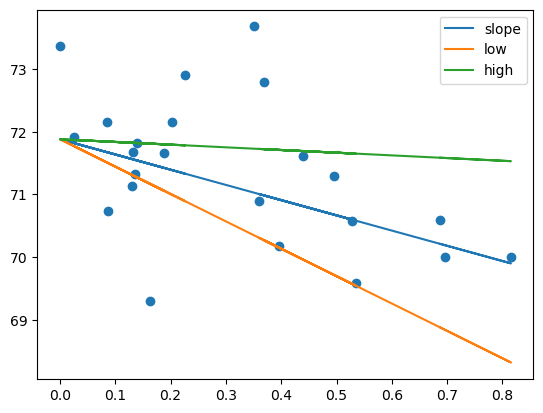

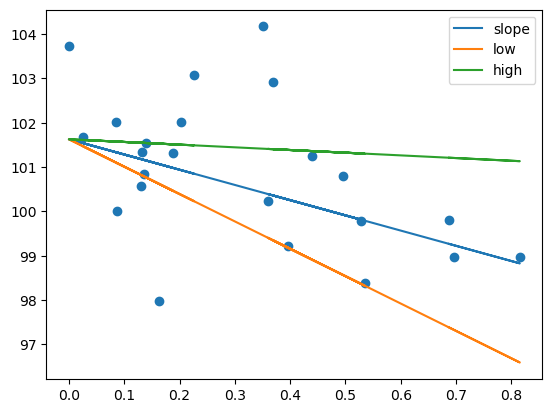

In [50]:
# Define time period
timeslice_trend=slice(start_year,end_year)
var = cc_season
Y = var.sel(year=timeslice_trend)
Y_rel = Y/var.sel(year=start_year).values*100
X = temp_ERA5_annual.sel(year=timeslice_trend) - temp_ERA5_annual.sel(year=timeslice_trend).min('year')

slope, intercept, low, high = stats.theilslopes(Y, X)
slope_rel, intercept_rel, low_rel, high_rel = stats.theilslopes(Y_rel, X)

print(slope_rel)
print(low_rel)
print(high_rel)
print(' ')
print(slope/var.sel(year=start_year).values*100)
print(low/var.sel(year=start_year).values*100)
print(high/var.sel(year=start_year).values*100)

plt.scatter(X, Y)
plt.plot(X, intercept + slope*X, label='slope')
plt.plot(X, intercept + low*X, label='low')
plt.plot(X, intercept + high*X, label='high')
plt.legend()
plt.show()

plt.scatter(X, Y_rel)
plt.plot(X, intercept_rel + slope_rel*X, label='slope')
plt.plot(X, intercept_rel + low_rel*X, label='low')
plt.plot(X, intercept_rel + high_rel*X, label='high')
plt.legend()
plt.show()

## Model data

In [78]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
timeslice=slice('2040-01-01','2069-12-31')
z_value = 2.045 # 95 % confidence level, n-1=29 (t-value)

In [79]:

ds_piClim = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.clm.concatfiles.nc')
ds_2xCO2 = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.clm.concatfiles.nc')
ds_4xCO2 = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.clm.concatfiles.nc')

# Fix time stamp
ds_piClim = functions.fix_clm_time(ds_piClim)
ds_2xCO2 = functions.fix_clm_time(ds_2xCO2)
ds_4xCO2 = functions.fix_clm_time(ds_4xCO2)

# Select timeslice
ds_piClim = ds_piClim.sel(time=timeslice)
ds_2xCO2 = ds_2xCO2.sel(time=timeslice)
ds_4xCO2 = ds_4xCO2.sel(time=timeslice)

# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
for ds in ds_list:
    tmp = ds['SOILICE'] + ds['SOILLIQ']
    tmp = tmp.sel(levsoi=0) + tmp.sel(levsoi=1) + 2/3*tmp.sel(levsoi=2)
    ds['SOILWATER_10CM_corrected'] = tmp

In [80]:
ds_cloud_piClim = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_piClim.nc')
ds_cloud_2xCO2 = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_abrupt-2xCO2.nc')
ds_cloud_4xCO2 = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_abrupt-4xCO2.nc')

ds_cloud_piClim = ds_cloud_piClim.sel(time=timeslice)
ds_cloud_2xCO2 = ds_cloud_2xCO2.sel(time=timeslice)
ds_cloud_4xCO2 = ds_cloud_4xCO2.sel(time=timeslice)

files = glob.glob(rpath+'feedback_input/interval30/tas_piClim*.nc')
files.sort()
print(files)
ds_tas_piClim = xr.open_mfdataset(files)
ds_tas_2xCO2 = xr.open_dataset(rpath+'feedback_input/tas_abrupt-2xCO2_1920-01-01_2069-12-31.nc')
ds_tas_4xCO2 = xr.open_dataset(rpath+'feedback_input/tas_abrupt-4xCO2_1920-01-01_2069-12-31.nc')

ds_tas_piClim = ds_tas_piClim.sel(time=timeslice)
ds_tas_2xCO2 = ds_tas_2xCO2.sel(time=timeslice)
ds_tas_4xCO2 = ds_tas_4xCO2.sel(time=timeslice)


['/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedback_input/interval30/tas_piClim_1920-01-01_1949-12-31.nc', '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedback_input/interval30/tas_piClim_1950-01-01_1979-12-31.nc', '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedback_input/interval30/tas_piClim_1980-01-01_2009-12-31.nc', '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedback_input/interval30/tas_piClim_2010-01-01_2039-12-31.nc', '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedback_input/interval30/tas_piClim_2040-01-01_2069-12-31.nc']


In [81]:
# Get area fraction

ds_piClim_area = xr.open_dataset(rpath+'land_vars/clm_piClim.nc')
ds_piClim_area = ds_piClim_area['area']

In [82]:
# Get land mask

landmask = xr.open_dataset(rpath+'other_cloud_vars/LANDFRAC_piClim.nc')
landmask = landmask['LANDFRAC'].isel(time=0)

In [83]:
ds_piClim = ds_piClim.drop_vars('time_bounds')
ds_2xCO2 = ds_2xCO2.drop_vars('time_bounds')
ds_4xCO2 = ds_4xCO2.drop_vars('time_bounds')

In [84]:
# Create Arctic averages over land excluding greenland

area_weights = ds_piClim_area.sel(lat=slice(Arctic_limit,90),lon=land_longitudes)/(ds_piClim_area.sel(lat=slice(Arctic_limit,90),lon=land_longitudes).sum())
ds_piClim_Arctic = (ds_piClim.sel(lat=slice(Arctic_limit,90), lon=land_longitudes)*area_weights).sum(dim=['lon','lat'])
ds_2xCO2_Arctic = (ds_2xCO2.sel(lat=slice(Arctic_limit,90), lon=land_longitudes)*area_weights).sum(dim=['lon','lat'])
ds_4xCO2_Arctic = (ds_4xCO2.sel(lat=slice(Arctic_limit,90), lon=land_longitudes)*area_weights).sum(dim=['lon','lat'])

ds_cloud_piClim_Arctic = functions.computeWeightedMeanMasked(ds_cloud_piClim.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes), landmask.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes))
ds_cloud_2xCO2_Arctic = functions.computeWeightedMeanMasked(ds_cloud_2xCO2.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes), landmask.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes))
ds_cloud_4xCO2_Arctic = functions.computeWeightedMeanMasked(ds_cloud_4xCO2.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes), landmask.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes))

ds_piClim_Arctic = xr.merge([ds_piClim_Arctic,ds_cloud_piClim_Arctic])
ds_2xCO2_Arctic = xr.merge([ds_2xCO2_Arctic,ds_cloud_2xCO2_Arctic])
ds_4xCO2_Arctic = xr.merge([ds_4xCO2_Arctic,ds_cloud_4xCO2_Arctic])

In [85]:
# Calculate global average

ds_tas_piClim_global = functions.computeWeightedMean(ds_tas_piClim['tas'])
ds_tas_2xCO2_global = functions.computeWeightedMean(ds_tas_2xCO2['tas'])
ds_tas_4xCO2_global = functions.computeWeightedMean(ds_tas_4xCO2['tas'])

In [86]:
# Create temporal averages and standard deviation

# Select spring and summer months

ds_piClim_spring_summer = ds_piClim_Arctic.sel(time = ds_piClim_Arctic['time.month'].isin(spring_summer_months))
ds_piClim_spring_summer = ds_piClim_spring_summer.groupby(ds_piClim_spring_summer['time.year']).mean('time')

ds_2xCO2_spring_summer = ds_2xCO2_Arctic.sel(time = ds_2xCO2_Arctic['time.month'].isin(spring_summer_months))
ds_2xCO2_spring_summer = ds_2xCO2_spring_summer.groupby(ds_2xCO2_spring_summer['time.year']).mean('time')

ds_4xCO2_spring_summer = ds_4xCO2_Arctic.sel(time = ds_4xCO2_Arctic['time.month'].isin(spring_summer_months))
ds_4xCO2_spring_summer = ds_4xCO2_spring_summer.groupby(ds_4xCO2_spring_summer['time.year']).mean('time')


# Select summer months

ds_piClim_summer = ds_piClim_Arctic.sel(time = ds_piClim_Arctic['time.month'].isin(summer_months))
ds_piClim_summer = ds_piClim_summer.groupby(ds_piClim_summer['time.year']).mean('time')

ds_2xCO2_summer = ds_2xCO2_Arctic.sel(time = ds_2xCO2_Arctic['time.month'].isin(summer_months))
ds_2xCO2_summer = ds_2xCO2_summer.groupby(ds_2xCO2_summer['time.year']).mean('time')

ds_4xCO2_summer = ds_4xCO2_Arctic.sel(time = ds_4xCO2_Arctic['time.month'].isin(summer_months))
ds_4xCO2_summer = ds_4xCO2_summer.groupby(ds_4xCO2_summer['time.year']).mean('time')

# Select annual mean 

ds_tas_piClim_annual = ds_tas_piClim_global.groupby(ds_tas_piClim_global['time.year']).mean('time')
ds_tas_2xCO2_annual = ds_tas_2xCO2_global.groupby(ds_tas_2xCO2_global['time.year']).mean('time')
ds_tas_4xCO2_annual = ds_tas_4xCO2_global.groupby(ds_tas_4xCO2_global['time.year']).mean('time')

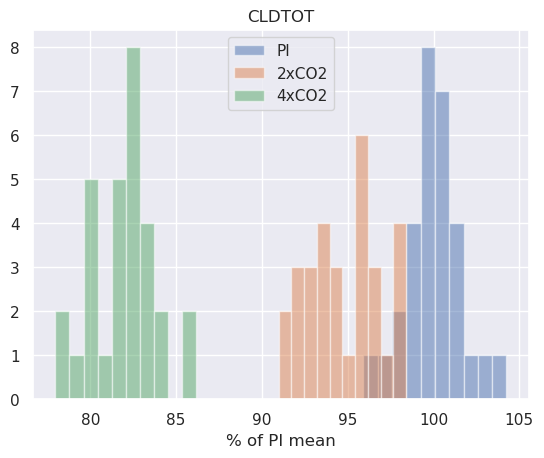

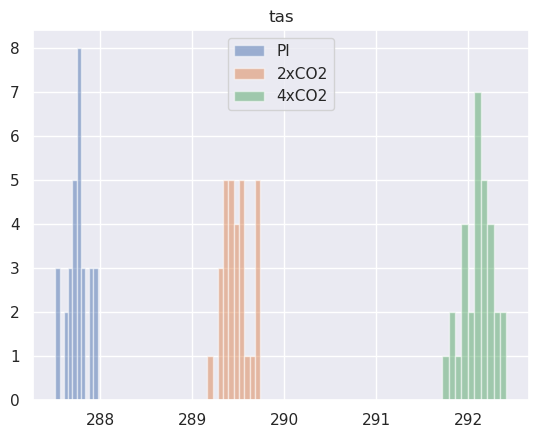

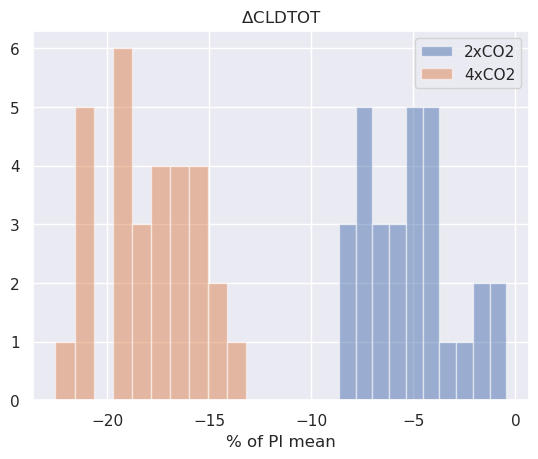

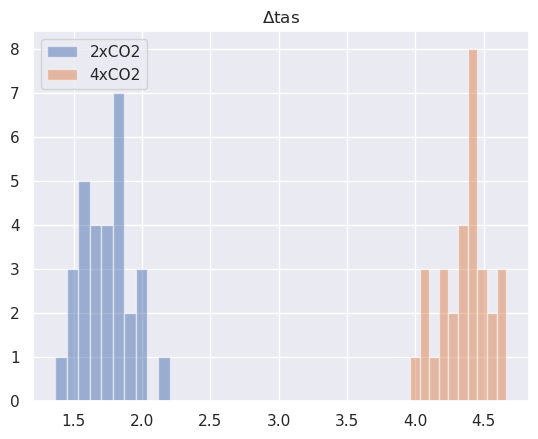

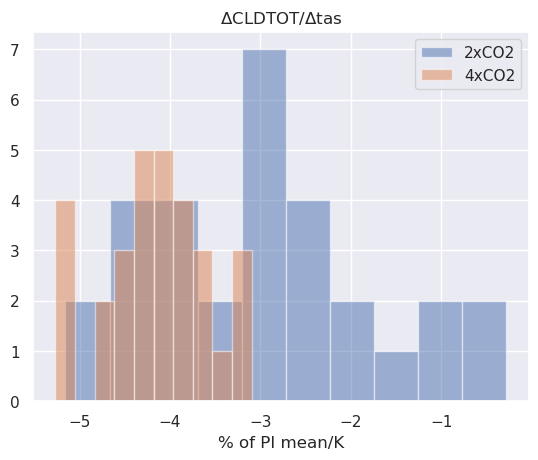

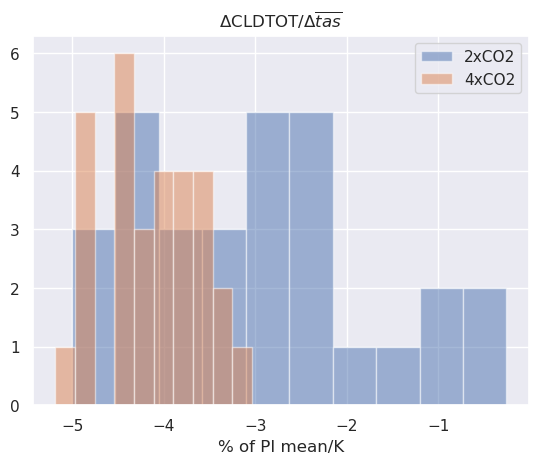

4xCO2
Difference between variable mean
-18.032036876813038
-18.032036876813024
Difference between variable mean by temperature change
-4.144978018263528
-4.153893542531299
Difference between variable std by temperature change
0.5379964584888276
0.5832880198822555
2xCO2
Difference between variable mean
-5.179145465509858
-5.179145465509848
Difference between variable mean by temperature change
-2.9918953546929234
-2.9785429252013955
Difference between variable std by temperature change
1.3089068045543975
1.248066661011619


In [104]:
var = 'CLDTOT'
ds_piClim_season = ds_piClim_summer/ds_piClim_summer.mean('year')*100
ds_2xCO2_season = ds_2xCO2_summer/ds_piClim_summer.mean('year')*100
ds_4xCO2_season = ds_4xCO2_summer/ds_piClim_summer.mean('year')*100

plt.hist(ds_piClim_season[var], alpha=0.5, label='PI')
plt.hist(ds_2xCO2_season[var], alpha=0.5, label='2xCO2')
plt.hist(ds_4xCO2_season[var], alpha=0.5, label='4xCO2')
plt.xlabel('% of PI mean')
plt.legend()
plt.title(var)
plt.show()

plt.hist(ds_tas_piClim_annual, alpha=0.5, label='PI')
plt.hist(ds_tas_2xCO2_annual, alpha=0.5, label='2xCO2')
plt.hist(ds_tas_4xCO2_annual, alpha=0.5, label='4xCO2')
plt.legend()
plt.title('tas')
plt.show()

plt.hist(ds_2xCO2_season[var]-ds_piClim_season[var], alpha=0.5, label='2xCO2')
plt.hist(ds_4xCO2_season[var]-ds_piClim_season[var], alpha=0.5, label='4xCO2')
plt.xlabel('% of PI mean')
plt.legend()
plt.title('$\Delta$'+var)
plt.show()

plt.hist(ds_tas_2xCO2_annual-ds_tas_piClim_annual, alpha=0.5, label='2xCO2')
plt.hist(ds_tas_4xCO2_annual-ds_tas_piClim_annual, alpha=0.5, label='4xCO2')
plt.legend()
plt.title('$\Delta$tas')
plt.show()

plt.hist((ds_2xCO2_season[var]-ds_piClim_season[var])/(ds_tas_2xCO2_annual-ds_tas_piClim_annual), alpha=0.5, label='2xCO2')
plt.hist((ds_4xCO2_season[var]-ds_piClim_season[var])/(ds_tas_4xCO2_annual-ds_tas_piClim_annual), alpha=0.5, label='4xCO2')
plt.xlabel('% of PI mean/K')
plt.legend()
plt.title('$\Delta$'+var+'/$\Delta$tas')
plt.show()

plt.hist((ds_2xCO2_season[var]-ds_piClim_season[var])/(ds_tas_2xCO2_annual-ds_tas_piClim_annual).mean('year'), alpha=0.5, label='2xCO2')
plt.hist((ds_4xCO2_season[var]-ds_piClim_season[var])/(ds_tas_4xCO2_annual-ds_tas_piClim_annual).mean('year'), alpha=0.5, label='4xCO2')
plt.legend()
plt.xlabel('% of PI mean/K')
plt.title('$\Delta$'+var+'/$\Delta\overline{tas}$')
plt.show()

print('4xCO2')
print('Difference between variable mean')
print((ds_4xCO2_season[var]-ds_piClim_season[var]).mean('year').values)
print((ds_4xCO2_season[var].mean('year')-ds_piClim_season[var].mean('year')).values)

print('Difference between variable mean by temperature change')
print((((ds_4xCO2_season[var]-ds_piClim_season[var]).mean('year'))/(ds_tas_4xCO2_annual-ds_tas_piClim_annual).mean('year')).values)
print((((ds_4xCO2_season[var]-ds_piClim_season[var])/(ds_tas_4xCO2_annual-ds_tas_piClim_annual)).mean('year')).values)

print('Difference between variable std by temperature change')
print((((ds_4xCO2_season[var]-ds_piClim_season[var]).std('year'))/(ds_tas_4xCO2_annual-ds_tas_piClim_annual).mean('year')).values)
print((((ds_4xCO2_season[var]-ds_piClim_season[var])/(ds_tas_4xCO2_annual-ds_tas_piClim_annual)).std('year')).values)

print('2xCO2')
print('Difference between variable mean')
print((ds_2xCO2_season[var]-ds_piClim_season[var]).mean('year').values)
print((ds_2xCO2_season[var].mean('year')-ds_piClim_season[var].mean('year')).values)

print('Difference between variable mean by temperature change')
print((((ds_2xCO2_season[var]-ds_piClim_season[var]).mean('year'))/(ds_tas_2xCO2_annual-ds_tas_piClim_annual).mean('year')).values)
print((((ds_2xCO2_season[var]-ds_piClim_season[var])/(ds_tas_2xCO2_annual-ds_tas_piClim_annual)).mean('year')).values)

print('Difference between variable std by temperature change')
print((((ds_2xCO2_season[var]-ds_piClim_season[var]).std('year'))/(ds_tas_2xCO2_annual-ds_tas_piClim_annual).mean('year')).values)
print((((ds_2xCO2_season[var]-ds_piClim_season[var])/(ds_tas_2xCO2_annual-ds_tas_piClim_annual)).std('year')).values)

In [ ]:
# Compute absolute changes
ds_2xCO2_spring_summer_abs = ds_2xCO2_spring_summer-ds_piClim_spring_summer
ds_4xCO2_spring_summer_abs = ds_4xCO2_spring_summer-ds_piClim_spring_summer

ds_2xCO2_summer_abs = ds_2xCO2_summer-ds_piClim_summer
ds_4xCO2_summer_abs = ds_4xCO2_summer-ds_piClim_summer

ds_deltaT_2xCO2 = ds_tas_2xCO2_annual - ds_tas_piClim_annual
ds_deltaT_4xCO2 = ds_tas_4xCO2_annual - ds_tas_piClim_annual

# Compute relative changes
ds_2xCO2_spring_summer_rel = ds_2xCO2_spring_summer_abs/ds_piClim_spring_summer.mean('year')*100
ds_4xCO2_spring_summer_rel = ds_4xCO2_spring_summer_abs/ds_piClim_spring_summer.mean('year')*100

ds_2xCO2_summer_rel = ds_2xCO2_summer_abs/ds_piClim_summer.mean('year')*100
ds_4xCO2_summer_rel = ds_4xCO2_summer_abs/ds_piClim_summer.mean('year')*100

In [88]:
# Compute absolute changes
ds_2xCO2_spring_summer_abs_mean = (ds_2xCO2_spring_summer_abs/ds_deltaT_2xCO2).mean('year')
ds_4xCO2_spring_summer_abs_mean = (ds_4xCO2_spring_summer_abs/ds_deltaT_4xCO2).mean('year')

ds_2xCO2_summer_abs_mean = (ds_2xCO2_summer_abs/ds_deltaT_2xCO2).mean('year')
ds_4xCO2_summer_abs_mean = (ds_4xCO2_summer_abs/ds_deltaT_4xCO2).mean('year')

# Compute relative changes
ds_2xCO2_spring_summer_rel_mean = (ds_2xCO2_spring_summer_rel/ds_deltaT_2xCO2).mean('year')
ds_4xCO2_spring_summer_rel_mean = (ds_4xCO2_spring_summer_rel/ds_deltaT_4xCO2).mean('year')

ds_2xCO2_summer_rel_mean = (ds_2xCO2_summer_rel/ds_deltaT_2xCO2).mean('year')
ds_4xCO2_summer_rel_mean = (ds_4xCO2_summer_rel/ds_deltaT_4xCO2).mean('year')

In [ ]:
# Calculate standard deviations for distributions


# Compute absolute changes
ds_2xCO2_spring_summer_abs_std = (ds_2xCO2_spring_summer_abs/ds_deltaT_2xCO2).std('year')
ds_4xCO2_spring_summer_abs_std = (ds_4xCO2_spring_summer_abs/ds_deltaT_4xCO2).std('year')

ds_2xCO2_summer_abs_std = (ds_2xCO2_summer_abs/ds_deltaT_2xCO2).std('year')
ds_4xCO2_summer_abs_std = (ds_4xCO2_summer_abs/ds_deltaT_4xCO2).std('year')

ds_2xCO2_summer_abs_std_alt = (ds_2xCO2_summer_abs/(ds_deltaT_2xCO2).mean('year')).std('year')
ds_4xCO2_summer_abs_std_alt = (ds_4xCO2_summer_abs/(ds_deltaT_4xCO2).mean('year')).std('year')

# Compute relative changes
ds_2xCO2_spring_summer_rel_std = (ds_2xCO2_spring_summer_rel/ds_deltaT_2xCO2).std('year')
ds_4xCO2_spring_summer_rel_std = (ds_4xCO2_spring_summer_rel/ds_deltaT_4xCO2).std('year')

ds_2xCO2_summer_rel_std = (ds_2xCO2_summer_rel/ds_deltaT_2xCO2).std('year')
ds_4xCO2_summer_rel_std = (ds_4xCO2_summer_rel/ds_deltaT_4xCO2).std('year')

ds_2xCO2_summer_rel_std_alt = (ds_2xCO2_summer_rel/(ds_deltaT_2xCO2).mean('year')).std('year')
ds_4xCO2_summer_rel_std_alt = (ds_4xCO2_summer_rel/(ds_deltaT_4xCO2).mean('year')).std('year')

0.5832880198822561


In [108]:
# Calculate error margin
ds_2xCO2_spring_summer_std_err = z_value*ds_2xCO2_spring_summer_rel_std/np.sqrt(len(ds_2xCO2_spring_summer.year))
ds_4xCO2_spring_summer_std_err = z_value*ds_4xCO2_spring_summer_rel_std/np.sqrt(len(ds_4xCO2_spring_summer.year))

ds_2xCO2_summer_std_err = z_value*ds_2xCO2_summer_rel_std/np.sqrt(len(ds_2xCO2_summer.year))
ds_4xCO2_summer_std_err = z_value*ds_4xCO2_summer_rel_std/np.sqrt(len(ds_4xCO2_summer.year))

print(ds_4xCO2_summer_std_err['CLDTOT'].values)
print(ds_2xCO2_summer_std_err['CLDTOT'].values)

0.2177788707648695
0.4659834229567386


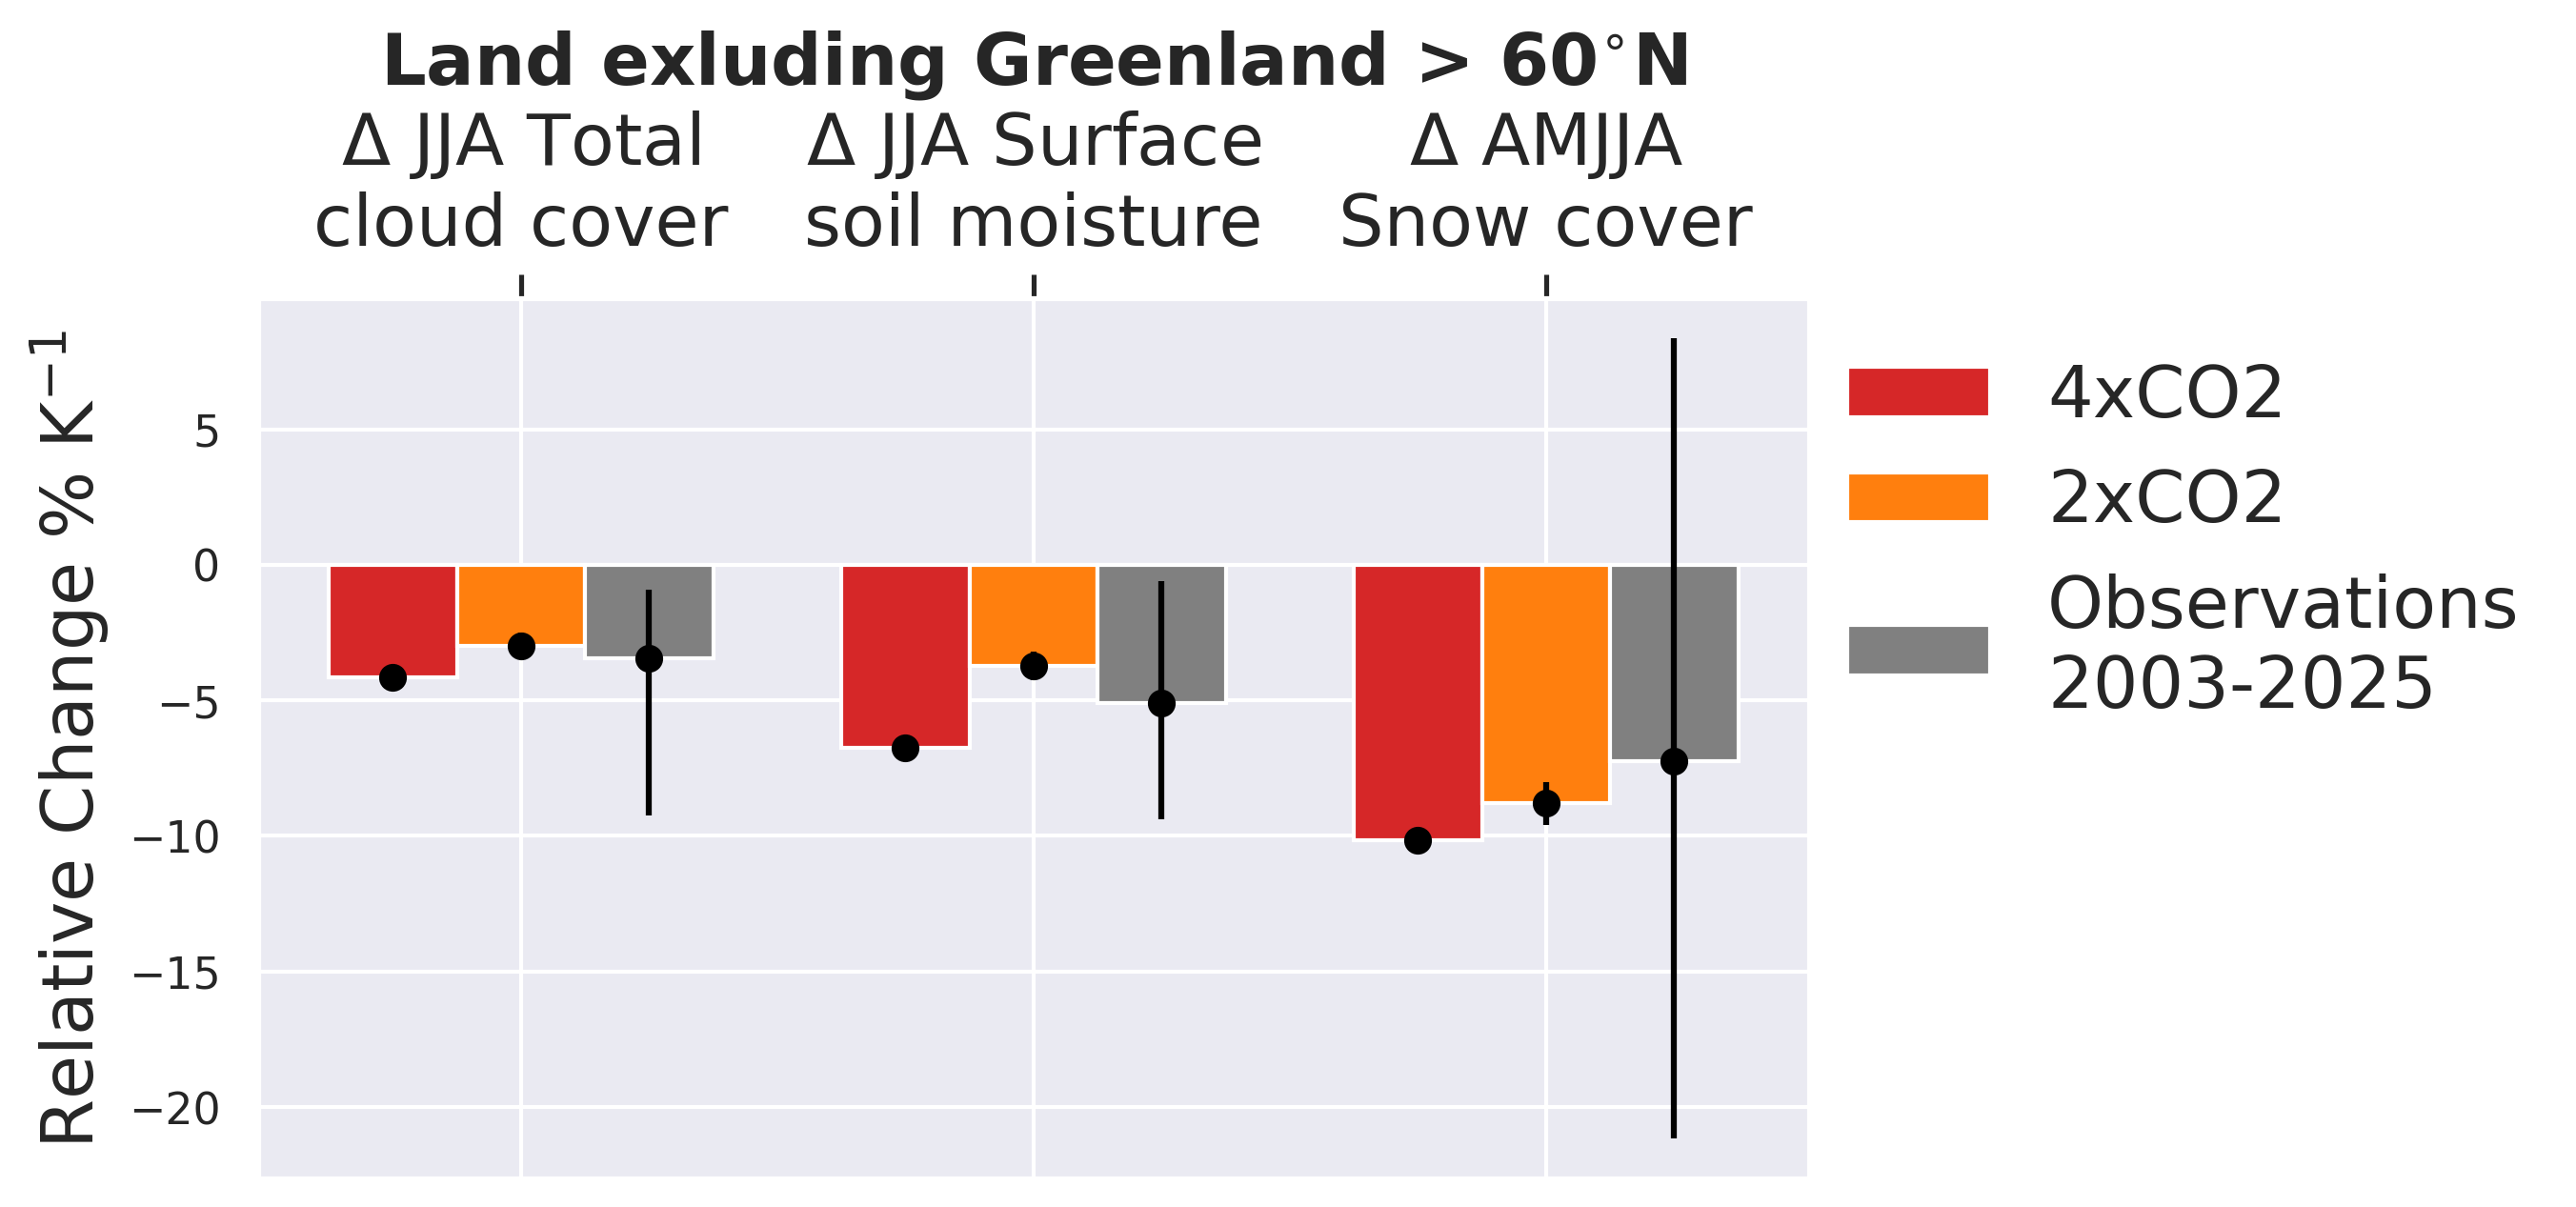

In [91]:
sns.set_theme()
fig, ax = plt.subplots(1, 1, figsize=[7, 4], dpi=300)

vars = ['$\Delta$ JJA Total\ncloud cover', '$\Delta$ JJA Surface\nsoil moisture', '$\Delta$ '+spring_summer_label+'\nSnow cover']
JJA_change = {
    '4xCO2': [ds_4xCO2_summer_rel_mean['CLDTOT'],
              ds_4xCO2_summer_rel_mean['SOILWATER_10CM_corrected'],
              ds_4xCO2_spring_summer_rel_mean['FSNO']],

    '2xCO2': [ds_2xCO2_summer_rel_mean['CLDTOT'],
              ds_2xCO2_summer_rel_mean['SOILWATER_10CM_corrected'],
              ds_2xCO2_spring_summer_rel_mean['FSNO']],
    
    'Observations\n2003-2025': [CERES_slope_rel,
                                SM_ERA5_slope_rel,
                                snow_slope_rel],
                                }

errors = [[ds_4xCO2_summer_std_err['CLDTOT'], ds_4xCO2_summer_std_err['SOILWATER_10CM_corrected'], ds_4xCO2_spring_summer_std_err['FSNO']],
           [ds_2xCO2_summer_std_err['CLDTOT'], ds_2xCO2_summer_std_err['SOILWATER_10CM_corrected'], ds_2xCO2_spring_summer_std_err['FSNO']],
           [(CERES_yerr_minus, SM_ERA5_yerr_minus, snow_yerr_minus),
            (CERES_yerr_plus, SM_ERA5_yerr_plus, snow_yerr_plus)]]

x = np.arange(len(vars))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0
colors = ['tab:red', 'tab:orange','grey']
for exp, measurement in JJA_change.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=exp, color=colors[multiplier])
    errorbars = ax.errorbar(x + offset, measurement, yerr=errors[multiplier], fmt="o", color="black")
    multiplier += 1

#ax.set_ylim([-25,3])
#ax.set_yscale('symlog')
ax.set_xticks(x + width, vars, fontsize=18)
ax.xaxis.tick_top()
#ax.set_xticks([-10, -8, -6, -4, 0], [-80, -60, -40, -20, 0], fontsize=18)
ax.set_ylabel('Relative Change % K$^{-1}$', fontsize=18)
ax.legend(loc='upper right', fontsize=18,bbox_to_anchor=[1.5,1],frameon=False)
ax.set_title('Land exluding Greenland > 60$^{\circ}$N',fontsize=18, fontweight='bold')

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig5.png',bbox_inches='tight')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig5.pdf',bbox_inches='tight')

In [107]:
# Calculate yerr just as the confidence interval in the difference between the two means
# Formula: https://www.thoughtco.com/sample-t-test-confidence-interval-example-4022456
SE_2xCO2_summer = np.sqrt(ds_2xCO2_summer_rel.var('year')/len(ds_2xCO2_summer_rel.year))
SE_4xCO2_summer = np.sqrt(ds_4xCO2_summer_rel.var('year')/len(ds_4xCO2_summer_rel.year))


SE_2xCO2_spring_summer = np.sqrt(ds_2xCO2_spring_summer_rel.var('year')/len(ds_2xCO2_spring_summer_rel.year))
SE_4xCO2_spring_summer = np.sqrt(ds_4xCO2_spring_summer_rel.var('year')/len(ds_4xCO2_spring_summer_rel.year))

ds_2xCO2_summer_std_err = z_value*SE_2xCO2_summer
ds_4xCO2_summer_std_err = z_value*SE_4xCO2_summer

ds_2xCO2_spring_summer_std_err = z_value*SE_2xCO2_spring_summer
ds_4xCO2_spring_summer_std_err = z_value*SE_4xCO2_spring_summer

print(ds_4xCO2_summer_std_err['CLDTOT'].values)
print(ds_2xCO2_summer_std_err['CLDTOT'].values)

0.8738455056686643
0.8459664116520108


In [ ]:
# Calculate yerr just as the confidence interval in the difference between the two means
# Formula: https://www.thoughtco.com/sample-t-test-confidence-interval-example-4022456
SE_2xCO2_summer = np.sqrt((ds_piClim_summer.var('year')/len(ds_piClim_summer.year) + ds_2xCO2_summer.var('year')/len(ds_2xCO2_summer.year)))
SE_4xCO2_summer = np.sqrt((ds_piClim_summer.var('year')/len(ds_piClim_summer.year) + ds_4xCO2_summer.var('year')/len(ds_4xCO2_summer.year)))


SE_2xCO2_spring_summer = np.sqrt((ds_piClim_spring_summer.var('year')/len(ds_piClim_spring_summer.year) + ds_2xCO2_spring_summer.var('year')/len(ds_2xCO2_spring_summer.year)))
SE_4xCO2_spring_summer = np.sqrt((ds_piClim_spring_summer.var('year')/len(ds_piClim_spring_summer.year) + ds_4xCO2_spring_summer.var('year')/len(ds_4xCO2_spring_summer.year)))


ds_2xCO2_summer_std_err = z_value*SE_2xCO2_summer
ds_4xCO2_summer_std_err = z_value*SE_4xCO2_summer

ds_2xCO2_spring_summer_std_err = z_value*SE_2xCO2_spring_summer
ds_4xCO2_spring_summer_std_err = z_value*SE_4xCO2_spring_summer


0.007939663635793515


In [98]:
# Calculate yerr just as the confidence interval in the difference between the two means
# Formula: https://www.thoughtco.com/sample-t-test-confidence-interval-example-4022456
S = ds_piClim_summer.mean('year')/100
SS = ds_piClim_spring_summer.mean('year')/100
SE_2xCO2_summer = np.sqrt(((ds_piClim_summer/S).var('year')/len(ds_piClim_summer.year) + (ds_2xCO2_summer/S).var('year')/len(ds_2xCO2_summer.year)))
SE_4xCO2_summer = np.sqrt(((ds_piClim_summer/S).var('year')/len(ds_piClim_summer.year) + (ds_4xCO2_summer/S).var('year')/len(ds_4xCO2_summer.year)))


SE_2xCO2_spring_summer = np.sqrt(((ds_piClim_spring_summer/SS).var('year')/len(ds_piClim_spring_summer.year) + (ds_2xCO2_spring_summer/SS).var('year')/len(ds_2xCO2_spring_summer.year)))
SE_4xCO2_spring_summer = np.sqrt(((ds_piClim_spring_summer/SS).var('year')/len(ds_piClim_spring_summer.year) + (ds_4xCO2_spring_summer/SS).var('year')/len(ds_4xCO2_spring_summer.year)))

ds_2xCO2_summer_std_err = z_value*SE_2xCO2_summer
ds_4xCO2_summer_std_err = z_value*SE_4xCO2_summer

ds_2xCO2_spring_summer_std_err = z_value*SE_2xCO2_spring_summer
ds_4xCO2_spring_summer_std_err = z_value*SE_4xCO2_spring_summer

print(ds_2xCO2_summer_std_err['CLDTOT'].values)

0.9799508640970905


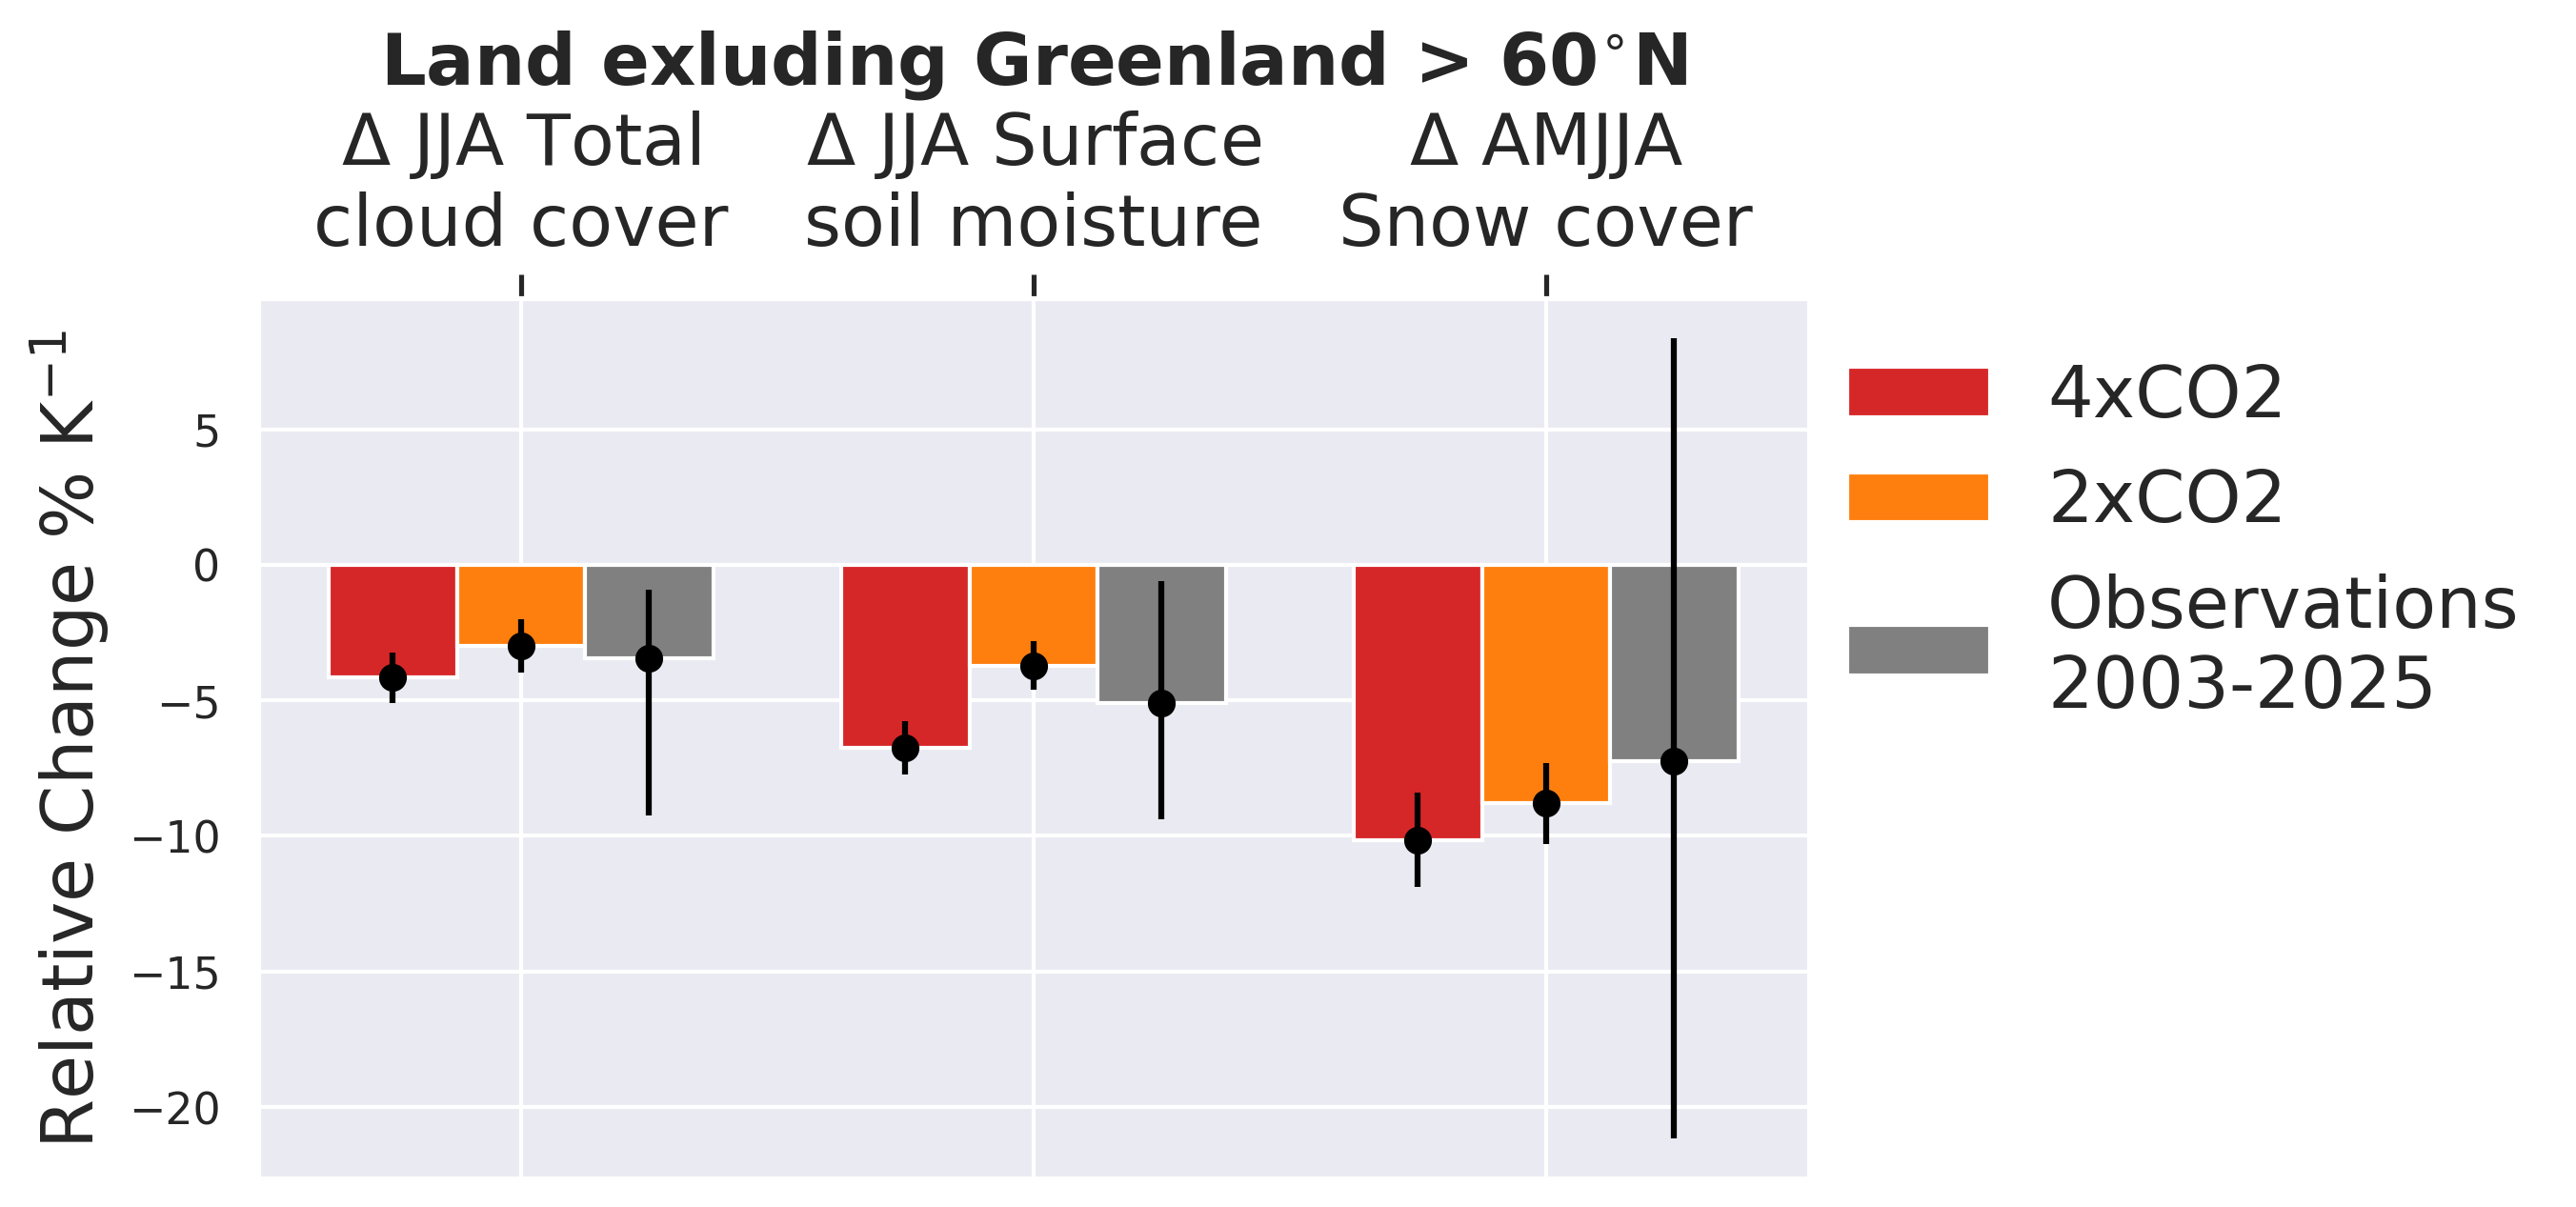

In [99]:
sns.set_theme()
fig, ax = plt.subplots(1, 1, figsize=[7, 4], dpi=300)

vars = ['$\Delta$ JJA Total\ncloud cover', '$\Delta$ JJA Surface\nsoil moisture', '$\Delta$ '+spring_summer_label+'\nSnow cover']
JJA_change = {
    '4xCO2': [ds_4xCO2_summer_rel_mean['CLDTOT'],
              ds_4xCO2_summer_rel_mean['SOILWATER_10CM_corrected'],
              ds_4xCO2_spring_summer_rel_mean['FSNO']],

    '2xCO2': [ds_2xCO2_summer_rel_mean['CLDTOT'],
              ds_2xCO2_summer_rel_mean['SOILWATER_10CM_corrected'],
              ds_2xCO2_spring_summer_rel_mean['FSNO']],
    
    'Observations\n2003-2025': [CERES_slope_rel,
                                SM_ERA5_slope_rel,
                                snow_slope_rel],
                                }

errors = [[ds_4xCO2_summer_std_err['CLDTOT'], ds_4xCO2_summer_std_err['SOILWATER_10CM_corrected'], ds_4xCO2_spring_summer_std_err['FSNO']],
           [ds_2xCO2_summer_std_err['CLDTOT'], ds_2xCO2_summer_std_err['SOILWATER_10CM_corrected'], ds_2xCO2_spring_summer_std_err['FSNO']],
           [(CERES_yerr_minus, SM_ERA5_yerr_minus, snow_yerr_minus),
            (CERES_yerr_plus, SM_ERA5_yerr_plus, snow_yerr_plus)]]

x = np.arange(len(vars))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0
colors = ['tab:red', 'tab:orange','grey']
for exp, measurement in JJA_change.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=exp, color=colors[multiplier])
    errorbars = ax.errorbar(x + offset, measurement, yerr=errors[multiplier], fmt="o", color="black")
    multiplier += 1

#ax.set_ylim([-25,3])
#ax.set_yscale('symlog')
ax.set_xticks(x + width, vars, fontsize=18)
ax.xaxis.tick_top()
#ax.set_xticks([-10, -8, -6, -4, 0], [-80, -60, -40, -20, 0], fontsize=18)
ax.set_ylabel('Relative Change % K$^{-1}$', fontsize=18)
ax.legend(loc='upper right', fontsize=18,bbox_to_anchor=[1.5,1],frameon=False)
ax.set_title('Land exluding Greenland > 60$^{\circ}$N',fontsize=18, fontweight='bold')

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig5.png',bbox_inches='tight')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig5.pdf',bbox_inches='tight')